<a href="https://colab.research.google.com/github/CHENNURUHARISH/PLANT-LEAF-DISEASE-DETECTION/blob/main/MOBILENET_PLANT_DISEASE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 457s 4s/step - accuracy: 0.2111 - loss: 3.1623 - val_accuracy: 0.5905 - val_loss: 1.8739 - learning_rate: 1.0000e-04
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 384ms/step - accuracy: 0.6984 - loss: 1.4542 - val_accuracy: 0.7093 - val_loss: 1.1642 - learning_rate: 1.0000e-04
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 383ms/step - accuracy: 0.7996 - loss: 0.8931 - val_accuracy: 0.7618 - val_loss: 0.9191 - learning_rate: 1.0000e-04
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 378ms/step - accuracy: 0.8304 - loss: 0.6884 - val_accuracy: 0.7926 - val_loss: 0.7858 - learning_rate: 1.0000e-04
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 379ms/step - accuracy: 0.8579 - loss: 0.5650 - val_accuracy: 0.8066 - val_loss: 0.7242 - learning_rate: 1.0000e-04
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 380ms/step - accuracy: 0.8740 

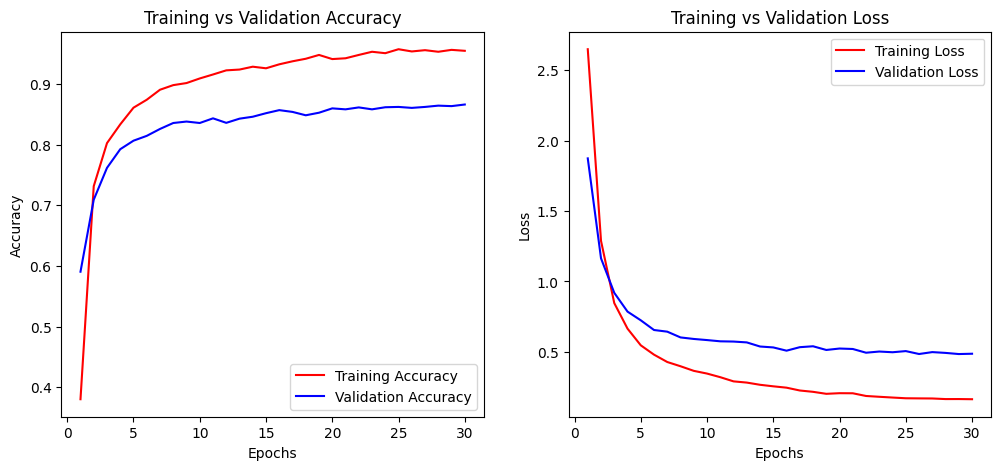

118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step


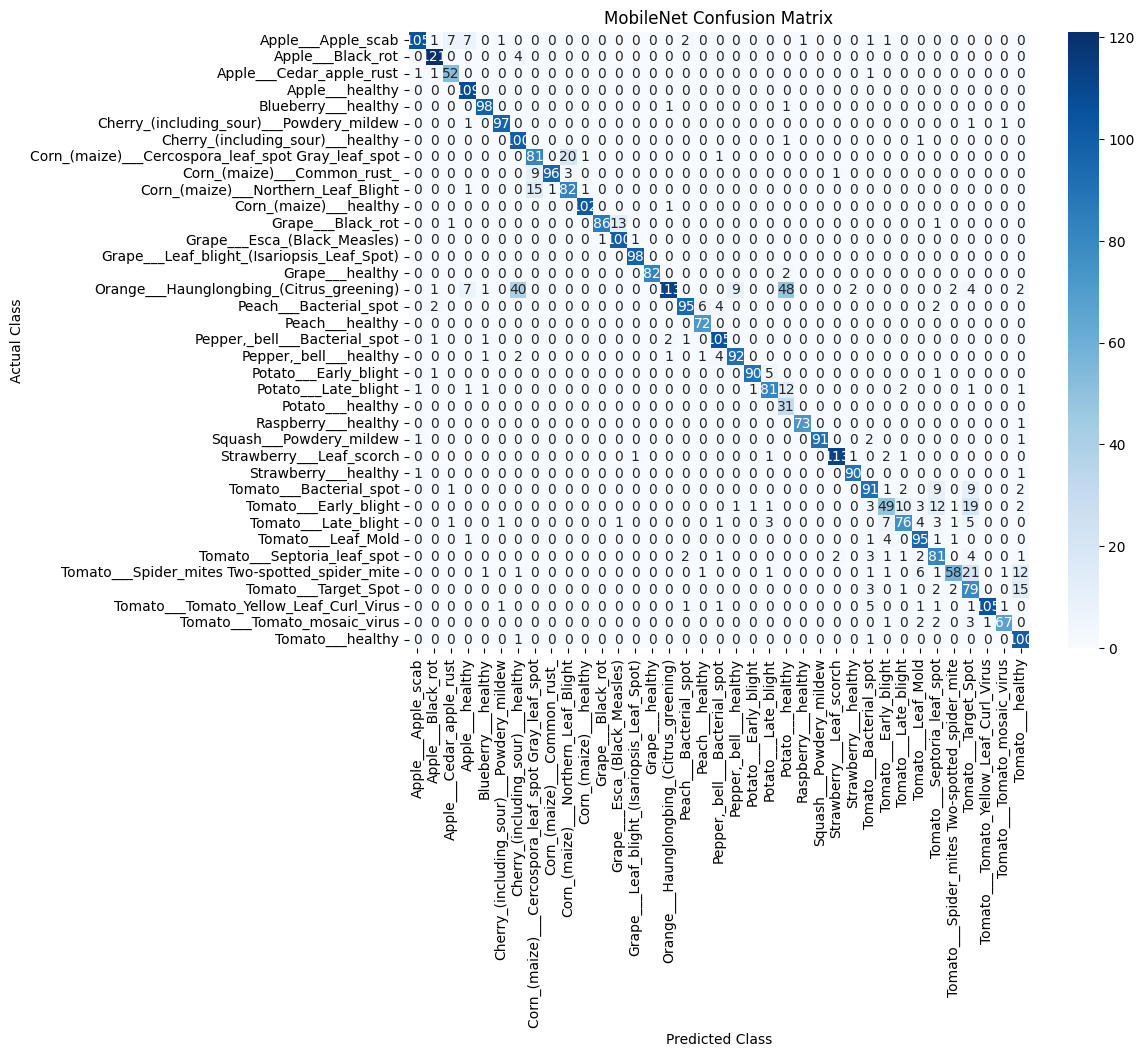

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

# Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

# Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

#  Define MobileNet Model
def build_mobilenet_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Build & Compile MobileNet Model
mobilenet_model = build_mobilenet_model(num_classes)
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Train the MobileNet Model
mobilenet_history = mobilenet_model.fit(train_dataset, validation_data=valid_dataset, epochs=30, callbacks=[lr_scheduler, early_stopping])

# Evaluate the Model on Validation Set
val_loss, val_acc = mobilenet_model.evaluate(valid_dataset)
print(f'\n MobileNet - Validation Accuracy: {val_acc:.4f}')
print(f' MobileNet - Validation Loss: {val_loss:.4f}')

# Evaluate the Model on Training Set
train_loss, train_acc = mobilenet_model.evaluate(train_dataset)
print(f'\n MobileNet - Training Accuracy: {train_acc:.4f}')  # Fixed label
print(f' MobileNet - Training Loss: {train_loss:.4f}')  # Fixed label

# Save the Model
mobilenet_model.save('mobilenet_plant_disease_model.keras')

#  Plot Accuracy & Loss Graphs
epochs = range(1, len(mobilenet_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

#  Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, mobilenet_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, mobilenet_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, mobilenet_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, mobilenet_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# 🔹 Evaluate with Confusion Matrix
y_pred = mobilenet_model.predict(valid_dataset)
predicted_categories = tf.argmax(y_pred, axis=1)

# Convert one-hot encoded labels to class indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)  # FIXED

cm_mobilenet = confusion_matrix(true_categories, predicted_categories)

# 🔹 Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('MobileNet Confusion Matrix')
plt.show()


Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 60s 436ms/step - accuracy: 0.1262 - loss: 3.4534 - val_accuracy: 0.5554 - val_loss: 2.1230 - learning_rate: 1.0000e-04
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 379ms/step - accuracy: 0.5214 - loss: 1.9325 - val_accuracy: 0.6995 - val_loss: 1.3394 - learning_rate: 1.0000e-04
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 382ms/step - accuracy: 0.6793 - loss: 1.3039 - val_accuracy: 0.7552 - val_loss: 1.0151 - learning_rate: 1.0000e-04
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 376ms/step - accuracy: 0.7412 - loss: 0.9717 - val_accuracy: 0.7777 - val_loss: 0.8562 - learning_rate: 1.0000e-04
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 379ms/step - accuracy: 0.7722 - loss: 0.8078 - val_accuracy: 0.7859 - val_loss: 0.7804 - learning_rate: 1.0000e-04
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 377ms/step - accuracy: 0.8070 - loss: 0.7084 - val_accuracy: 0.8008 - val_los

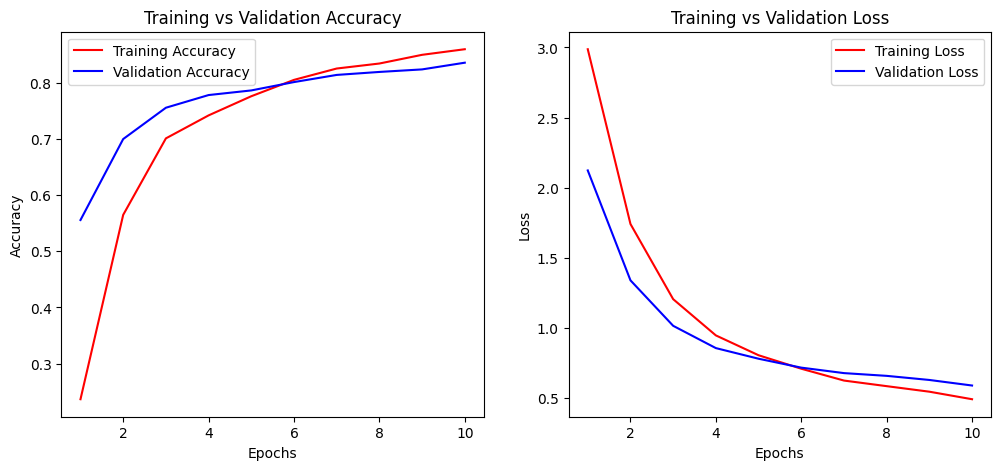

118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step


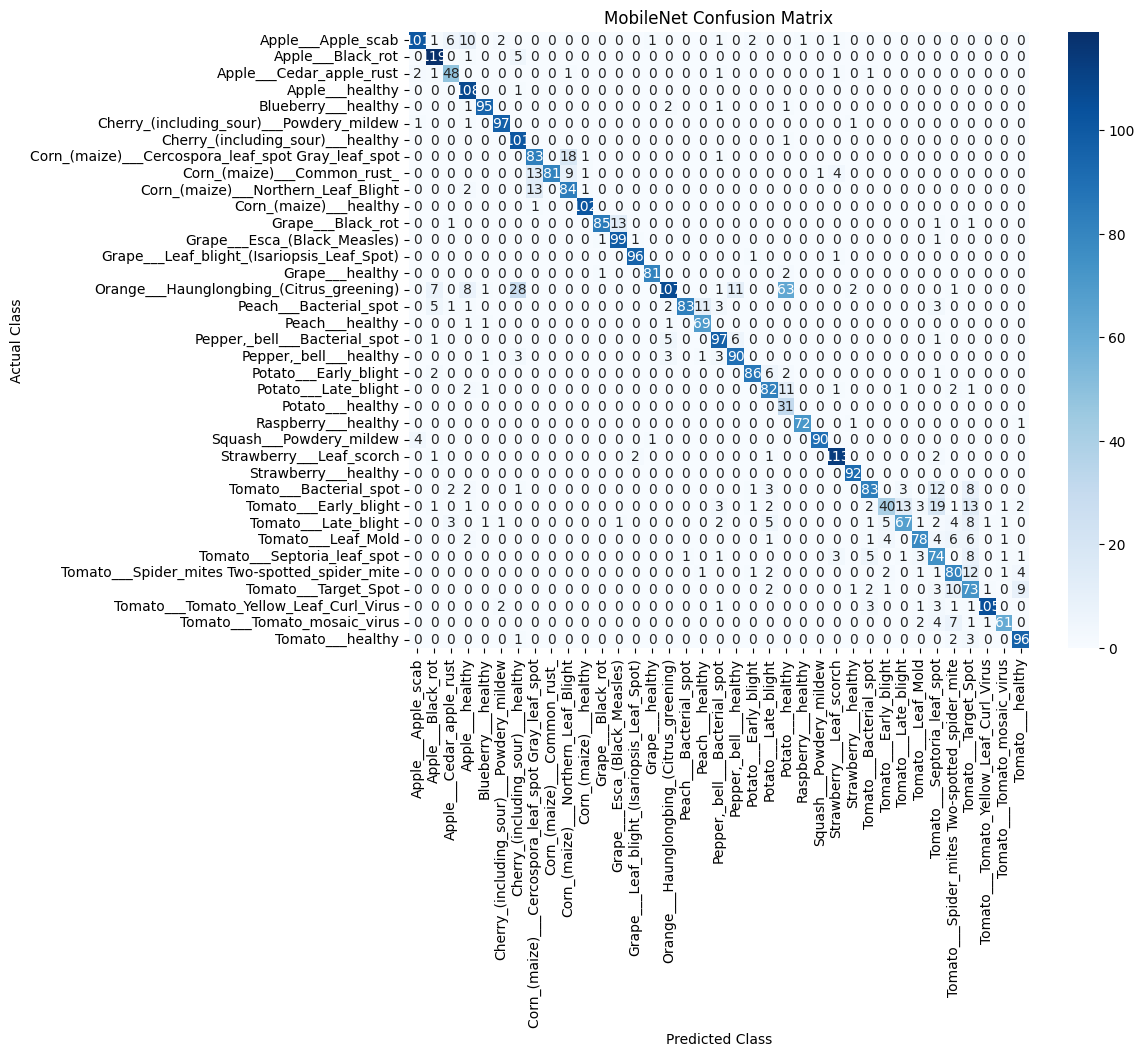

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

# Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

# Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 Define MobileNet Model
def build_mobilenet_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Build & Compile MobileNet Model
mobilenet_model = build_mobilenet_model(num_classes)
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Train the MobileNet Model
mobilenet_history = mobilenet_model.fit(train_dataset, validation_data=valid_dataset, epochs=10, callbacks=[lr_scheduler, early_stopping])

# Evaluate the Model on Validation Set
val_loss, val_acc = mobilenet_model.evaluate(valid_dataset)
print(f'\n MobileNet - Validation Accuracy: {val_acc:.4f}')
print(f' MobileNet - Validation Loss: {val_loss:.4f}')

# Evaluate the Model on Training Set
train_loss, train_acc = mobilenet_model.evaluate(train_dataset)
print(f'\n MobileNet - Training Accuracy: {train_acc:.4f}')  # Fixed label
print(f' MobileNet - Training Loss: {train_loss:.4f}')  # Fixed label

# Save the Model
mobilenet_model.save('mobilenet_plant_disease_model.keras')

# 🔹 Plot Accuracy & Loss Graphs
epochs = range(1, len(mobilenet_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

#  Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, mobilenet_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, mobilenet_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

#  Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, mobilenet_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, mobilenet_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

#  Evaluate with Confusion Matrix
y_pred = mobilenet_model.predict(valid_dataset)
predicted_categories = tf.argmax(y_pred, axis=1)

# Convert one-hot encoded labels to class indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)  # FIXED

cm_mobilenet = confusion_matrix(true_categories, predicted_categories)

#  Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('MobileNet Confusion Matrix')
plt.show()


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

# Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

# Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 Define MobileNet Model
def build_mobilenet_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Build & Compile MobileNet Model
mobilenet_model = build_mobilenet_model(num_classes)
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Train the MobileNet Model
mobilenet_history = mobilenet_model.fit(train_dataset, validation_data=valid_dataset, epochs=7, callbacks=[lr_scheduler, early_stopping])

# Evaluate the Model on Validation Set
val_loss, val_acc = mobilenet_model.evaluate(valid_dataset)
print(f'\n MobileNet - Validation Accuracy: {val_acc:.4f}')
print(f' MobileNet - Validation Loss: {val_loss:.4f}')

# Evaluate the Model on Training Set
train_loss, train_acc = mobilenet_model.evaluate(train_dataset)
print(f'\n MobileNet - Training Accuracy: {train_acc:.4f}')  # Fixed label
print(f' MobileNet - Training Loss: {train_loss:.4f}')  # Fixed label

# Save the Model
mobilenet_model.save('mobilenet_plant_disease_model.keras')

# 🔹 Plot Accuracy & Loss Graphs
epochs = range(1, len(mobilenet_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

#  Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, mobilenet_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, mobilenet_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

#  Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, mobilenet_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, mobilenet_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# 🔹 Evaluate with Confusion Matrix for Healthy vs Unhealthy

# Identify healthy and unhealthy classes
healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# Print all class names with index and label (Healthy / Unhealthy)
print("\n=== Full Class List ===")
for idx, cls in enumerate(class_names):
    label = "Healthy" if idx in healthy_class_indices else "Unhealthy"
    print(f"{idx:>2}: {cls:<30} → {label}")

# Predict with MobileNet Model (on the validation dataset)
y_pred_probs = mobilenet_model.predict(valid_dataset)
y_pred = tf.argmax(y_pred_probs, axis=1)

# Convert true labels to indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)

# Convert to binary classification (healthy=1, unhealthy=0)
y_true_binary = [1 if label in healthy_class_indices else 0 for label in true_categories.numpy()]
y_pred_binary = [1 if label in healthy_class_indices else 0 for label in y_pred.numpy()]

# Classification report and confusion matrix
print("\nHealthy vs Unhealthy Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"]))

# Compute confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

# Plot healthy/unhealthy confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Healthy vs Unhealthy Confusion Matrix")
plt.tight_layout()
plt.show()


Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 61s 435ms/step - accuracy: 0.1351 - loss: 3.3891 - val_accuracy: 0.5268 - val_loss: 2.1318 - learning_rate: 1.0000e-04
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 376ms/step - accuracy: 0.5294 - loss: 1.9275 - val_accuracy: 0.6817 - val_loss: 1.3526 - learning_rate: 1.0000e-04
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 374ms/step - accuracy: 0.6717 - loss: 1.2861 - val_accuracy: 0.7454 - val_loss: 1.0256 - learning_rate: 1.0000e-04
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 379ms/step - accuracy: 0.7308 - loss: 0.9947 - val_accuracy: 0.7716 - val_loss: 0.8681 - learning_rate: 1.0000e-04
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 381ms/step - accuracy: 0.7724 - loss: 0.8446 - val_accuracy: 0.7958 - val_loss: 0.7717 - learning_rate: 1.0000e-04
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 377ms/step - accuracy: 0.8031 - loss: 0.7258 - val_accuracy: 0.8053 - val_los

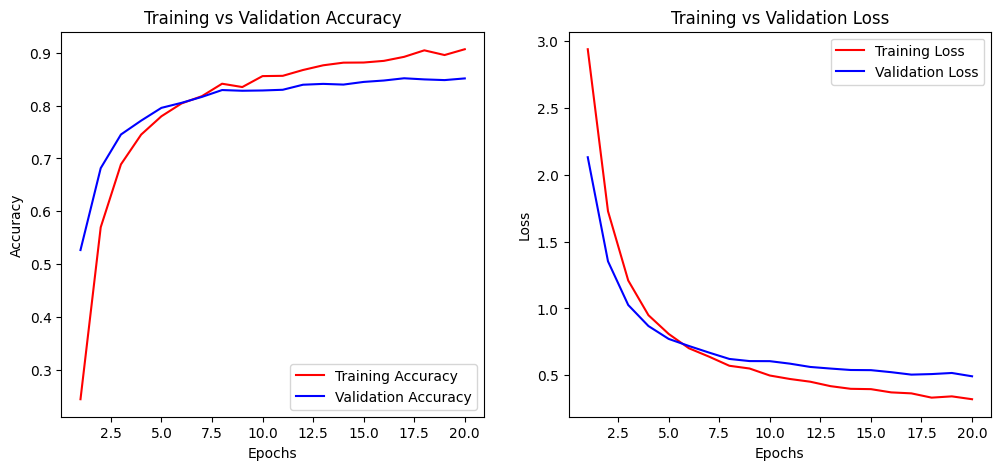


=== Full Class List ===
 0: Apple___Apple_scab             → Unhealthy
 1: Apple___Black_rot              → Unhealthy
 2: Apple___Cedar_apple_rust       → Unhealthy
 3: Apple___healthy                → Healthy
 4: Blueberry___healthy            → Healthy
 5: Cherry_(including_sour)___Powdery_mildew → Unhealthy
 6: Cherry_(including_sour)___healthy → Healthy
 7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Unhealthy
 8: Corn_(maize)___Common_rust_    → Unhealthy
 9: Corn_(maize)___Northern_Leaf_Blight → Unhealthy
10: Corn_(maize)___healthy         → Healthy
11: Grape___Black_rot              → Unhealthy
12: Grape___Esca_(Black_Measles)   → Unhealthy
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) → Unhealthy
14: Grape___healthy                → Healthy
15: Orange___Haunglongbing_(Citrus_greening) → Unhealthy
16: Peach___Bacterial_spot         → Unhealthy
17: Peach___healthy                → Healthy
18: Pepper,_bell___Bacterial_spot  → Unhealthy
19: Pepper,_bell___healthy        

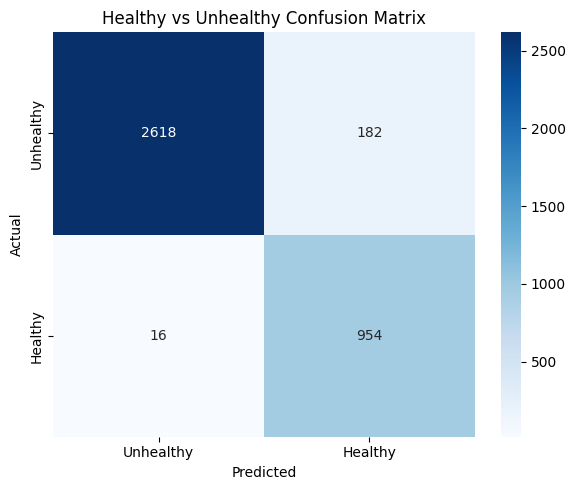

NameError: name 'metrics' is not defined

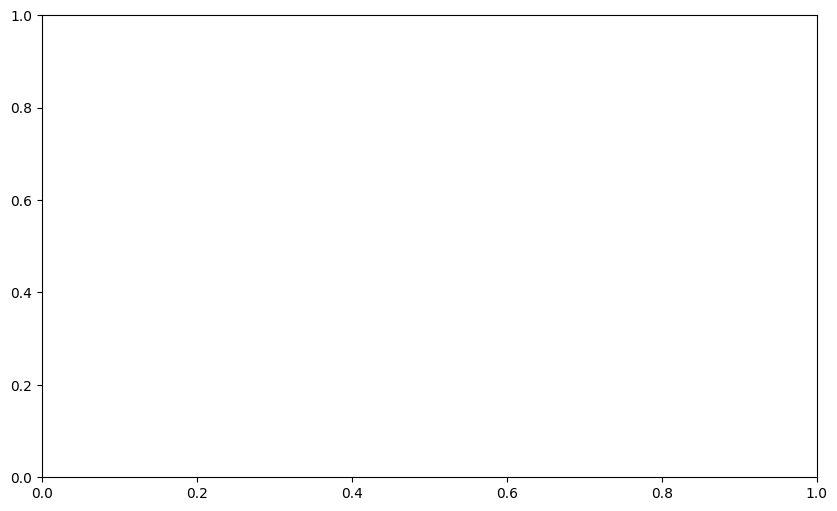

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

# Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

# Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 Define MobileNet Model
def build_mobilenet_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Build & Compile MobileNet Model
mobilenet_model = build_mobilenet_model(num_classes)
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Train the MobileNet Model
mobilenet_history = mobilenet_model.fit(train_dataset, validation_data=valid_dataset, epochs=20, callbacks=[lr_scheduler, early_stopping])

# Evaluate the Model on Validation Set
val_loss, val_acc = mobilenet_model.evaluate(valid_dataset)
print(f'\n MobileNet - Validation Accuracy: {val_acc:.4f}')
print(f' MobileNet - Validation Loss: {val_loss:.4f}')

# Evaluate the Model on Training Set
train_loss, train_acc = mobilenet_model.evaluate(train_dataset)
print(f'\n MobileNet - Training Accuracy: {train_acc:.4f}')  # Fixed label
print(f' MobileNet - Training Loss: {train_loss:.4f}')  # Fixed label

# Save the Model
mobilenet_model.save('mobilenet_plant_disease_model.keras')

# 🔹 Plot Accuracy & Loss Graphs
epochs = range(1, len(mobilenet_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

#  Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, mobilenet_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, mobilenet_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

#  Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, mobilenet_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, mobilenet_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# 🔹 Evaluate with Confusion Matrix for Healthy vs Unhealthy

# Identify healthy and unhealthy classes
healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# Print all class names with index and label (Healthy / Unhealthy)
print("\n=== Full Class List ===")
for idx, cls in enumerate(class_names):
    label = "Healthy" if idx in healthy_class_indices else "Unhealthy"
    print(f"{idx:>2}: {cls:<30} → {label}")

# Predict with MobileNet Model (on the validation dataset)
y_pred_probs = mobilenet_model.predict(valid_dataset)
y_pred = tf.argmax(y_pred_probs, axis=1)

# Convert true labels to indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)

# Convert to binary classification (healthy=1, unhealthy=0)
y_true_binary = [1 if label in healthy_class_indices else 0 for label in true_categories.numpy()]
y_pred_binary = [1 if label in healthy_class_indices else 0 for label in y_pred.numpy()]

# Classification report and confusion matrix
print("\nHealthy vs Unhealthy Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"]))

# Compute confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

# Plot healthy/unhealthy confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Healthy vs Unhealthy Confusion Matrix")
plt.tight_layout()
plt.show()



report = classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"], output_dict=True)
metrics = {
    'Precision': [report['Unhealthy']['precision'], report['Healthy']['precision']],
    'Recall': [report['Unhealthy']['recall'], report['Healthy']['recall']],
    'F1-Score': [report['Unhealthy']['f1-score'], report['Healthy']['f1-score']]
}

# Create an array for the x-axis positions of each group (Healthy, Unhealthy)
x = np.arange(2)  # Two classes: Unhealthy and Healthy
width = 0.2  # The width of the bars

# Create a single figure
fig, ax = plt.subplots(figsize=(10, 6))


# Add labels and title
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Precision, Recall, and F1-Score for Healthy vs Unhealthy')
ax.set_xticks(x)
ax.set_xticklabels(['Unhealthy', 'Healthy'])
ax.set_ylim(0, 1)  # Set the y-axis to go from 0 to 1 (since metrics are between 0 and 1)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step

Healthy vs Unhealthy Classification Report:
              precision    recall  f1-score   support

   Unhealthy       0.99      0.94      0.96      2800
     Healthy       0.84      0.98      0.91       970

    accuracy                           0.95      3770
   macro avg       0.92      0.96      0.93      3770
weighted avg       0.95      0.95      0.95      3770



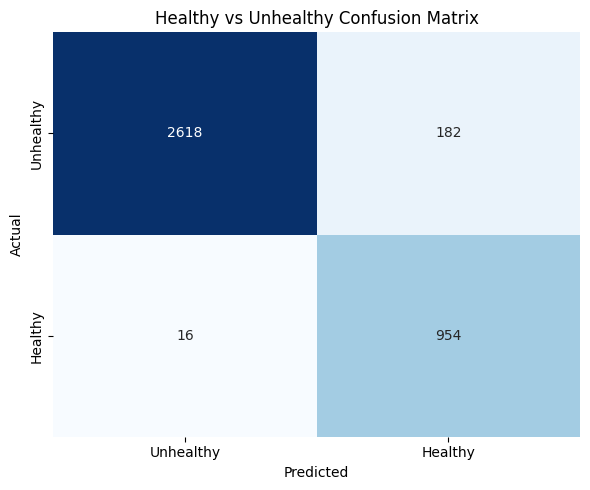

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Identify healthy and unhealthy classes
healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# Predict with MobileNet Model (on the validation dataset)
y_pred_probs = mobilenet_model.predict(valid_dataset)
y_pred = tf.argmax(y_pred_probs, axis=1)

# Convert true labels to indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)

# Convert to binary classification (healthy=1, unhealthy=0)
y_true_binary = [1 if label in healthy_class_indices else 0 for label in true_categories.numpy()]
y_pred_binary = [1 if label in healthy_class_indices else 0 for label in y_pred.numpy()]

# Classification report and confusion matrix
print("\nHealthy vs Unhealthy Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"]))

# Compute confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

# Plot healthy/unhealthy confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',cbar=False, xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Healthy vs Unhealthy Confusion Matrix")
plt.tight_layout()
plt.show()





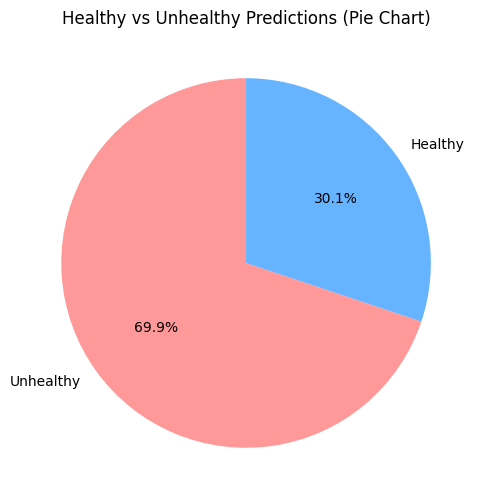

In [5]:
# Assuming you have predictions in y_pred_binary
labels = ['Unhealthy', 'Healthy']
sizes = [sum([1 for x in y_pred_binary if x == 0]), sum([1 for x in y_pred_binary if x == 1])]

# Plot Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title("Healthy vs Unhealthy Predictions (Pie Chart)")
plt.show()


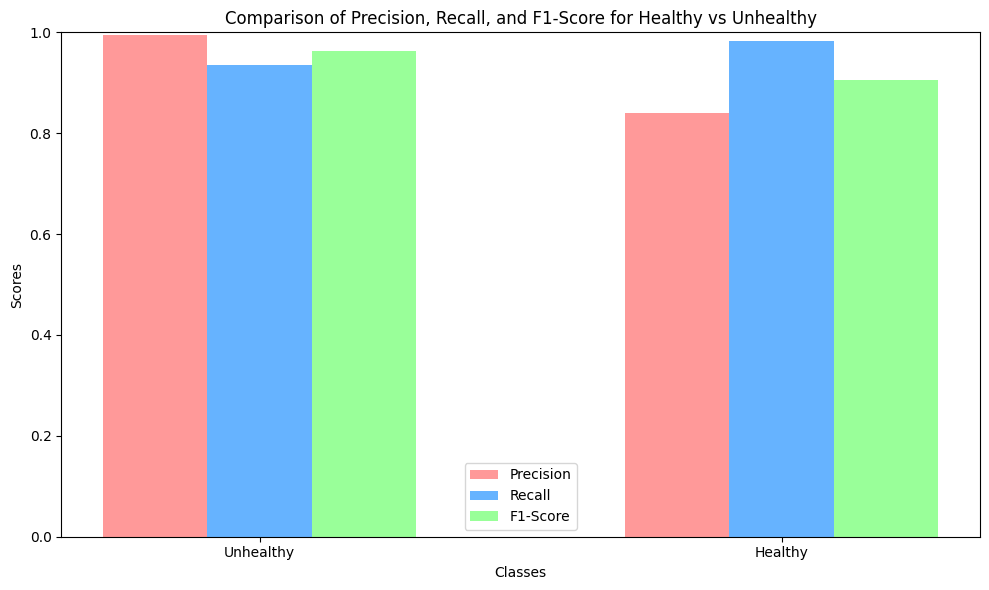

In [10]:
report = classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"], output_dict=True)
metrics = {
    'Precision': [report['Unhealthy']['precision'], report['Healthy']['precision']],
    'Recall': [report['Unhealthy']['recall'], report['Healthy']['recall']],
    'F1-Score': [report['Unhealthy']['f1-score'], report['Healthy']['f1-score']]
}



# Create an array for the x-axis positions of each group (Healthy, Unhealthy)
x = np.arange(2)  # Two classes: Unhealthy and Healthy
width = 0.2  # The width of the bars

# Create a single figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for each metric
ax.bar(x - width, metrics['Precision'], width, label='Precision', color='#ff9999')
ax.bar(x, metrics['Recall'], width, label='Recall', color='#66b3ff')
ax.bar(x + width, metrics['F1-Score'], width, label='F1-Score', color='#99ff99')

# Add labels and title
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Precision, Recall, and F1-Score for Healthy vs Unhealthy')
ax.set_xticks(x)
ax.set_xticklabels(['Unhealthy', 'Healthy'])
ax.set_ylim(0, 1)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 614s 5s/step - accuracy: 0.1328 - loss: 3.4274 - val_accuracy: 0.5430 - val_loss: 2.1155 - learning_rate: 1.0000e-04
Epoch 2/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 385ms/step - accuracy: 0.5239 - loss: 1.9290 - val_accuracy: 0.6833 - val_loss: 1.3626 - learning_rate: 1.0000e-04
Epoch 3/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 384ms/step - accuracy: 0.6689 - loss: 1.2904 - val_accuracy: 0.7438 - val_loss: 1.0481 - learning_rate: 1.0000e-04
Epoch 4/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 379ms/step - accuracy: 0.7348 - loss: 1.0078 - val_accuracy: 0.7692 - val_loss: 0.8947 - learning_rate: 1.0000e-04
Epoch 5/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 376ms/step - accuracy: 0.7795 - loss: 0.8130 - val_accuracy: 0.7899 - val_loss: 0.7972 - learning_rate: 1.0000e-04
Epoch 6/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 378ms/step - accuracy: 0.8055 

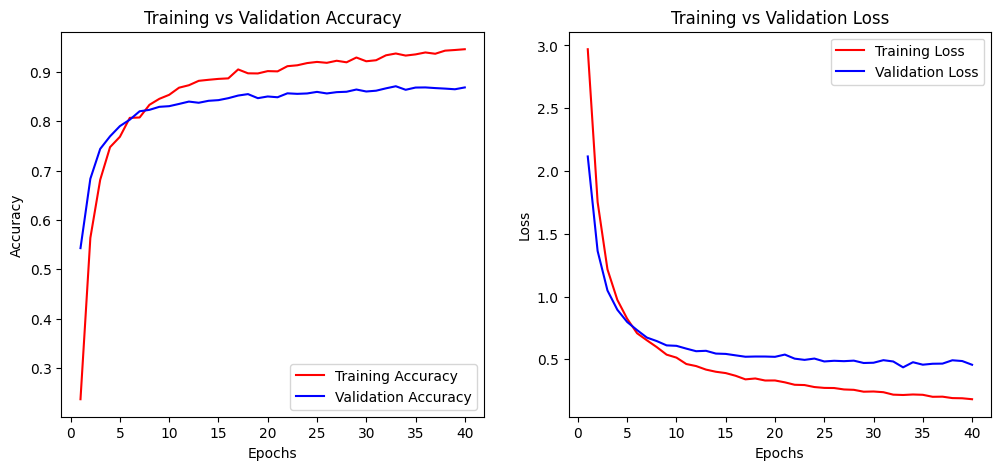


=== Full Class List ===
 0: Apple___Apple_scab             → Unhealthy
 1: Apple___Black_rot              → Unhealthy
 2: Apple___Cedar_apple_rust       → Unhealthy
 3: Apple___healthy                → Healthy
 4: Blueberry___healthy            → Healthy
 5: Cherry_(including_sour)___Powdery_mildew → Unhealthy
 6: Cherry_(including_sour)___healthy → Healthy
 7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Unhealthy
 8: Corn_(maize)___Common_rust_    → Unhealthy
 9: Corn_(maize)___Northern_Leaf_Blight → Unhealthy
10: Corn_(maize)___healthy         → Healthy
11: Grape___Black_rot              → Unhealthy
12: Grape___Esca_(Black_Measles)   → Unhealthy
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot) → Unhealthy
14: Grape___healthy                → Healthy
15: Orange___Haunglongbing_(Citrus_greening) → Unhealthy
16: Peach___Bacterial_spot         → Unhealthy
17: Peach___healthy                → Healthy
18: Pepper,_bell___Bacterial_spot  → Unhealthy
19: Pepper,_bell___healthy        

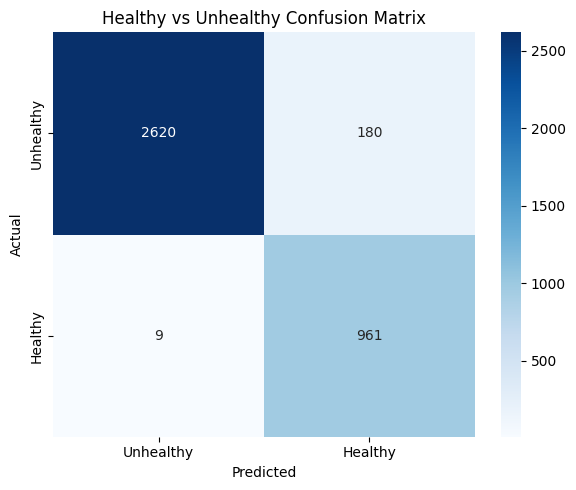

NameError: name 'np' is not defined

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

# Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

# Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 Define MobileNet Model
def build_mobilenet_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# Build & Compile MobileNet Model
mobilenet_model = build_mobilenet_model(num_classes)
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# Train the MobileNet Model
mobilenet_history = mobilenet_model.fit(train_dataset, validation_data=valid_dataset, epochs=40, callbacks=[lr_scheduler, early_stopping])

# Evaluate the Model on Validation Set
val_loss, val_acc = mobilenet_model.evaluate(valid_dataset)
print(f'\n MobileNet - Validation Accuracy: {val_acc:.4f}')
# print(f' MobileNet - Validation Loss: {val_loss:.4f}')

# Evaluate the Model on Training Set
train_loss, train_acc = mobilenet_model.evaluate(train_dataset)
print(f'\n MobileNet - Training Accuracy: {train_acc:.4f}')  # Fixed label
# print(f' MobileNet - Training Loss: {train_loss:.4f}')  # Fixed label

# Save the Model
mobilenet_model.save('mobilenet_plant_disease_model.keras')

#  Plot Accuracy & Loss Graphs
epochs = range(1, len(mobilenet_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

#  Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, mobilenet_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, mobilenet_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

#  Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, mobilenet_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, mobilenet_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# 🔹 Evaluate with Confusion Matrix for Healthy vs Unhealthy

# Identify healthy and unhealthy classes
healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# Print all class names with index and label (Healthy / Unhealthy)
print("\n=== Full Class List ===")
for idx, cls in enumerate(class_names):
    label = "Healthy" if idx in healthy_class_indices else "Unhealthy"
    print(f"{idx:>2}: {cls:<30} → {label}")

# Predict with MobileNet Model (on the validation dataset)
y_pred_probs = mobilenet_model.predict(valid_dataset)
y_pred = tf.argmax(y_pred_probs, axis=1)

# Convert true labels to indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)

# Convert to binary classification (healthy=1, unhealthy=0)
y_true_binary = [1 if label in healthy_class_indices else 0 for label in true_categories.numpy()]
y_pred_binary = [1 if label in healthy_class_indices else 0 for label in y_pred.numpy()]

# Classification report and confusion matrix
print("\nHealthy vs Unhealthy Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"]))

# Compute confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

# Plot healthy/unhealthy confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Healthy vs Unhealthy Confusion Matrix")
plt.tight_layout()
plt.show()



report = classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"], output_dict=True)
metrics = {
    'Precision': [report['Unhealthy']['precision'], report['Healthy']['precision']],
    'Recall': [report['Unhealthy']['recall'], report['Healthy']['recall']],
    'F1-Score': [report['Unhealthy']['f1-score'], report['Healthy']['f1-score']]
}

# # Create an array for the x-axis positions of each group (Healthy, Unhealthy)
# x = np.arange(2)  # Two classes: Unhealthy and Healthy
# width = 0.2  # The width of the bars

# # Create a single figure
# fig, ax = plt.subplots(figsize=(10, 6))


# # Add labels and title
# ax.set_xlabel('Classes')
# ax.set_ylabel('Scores')
# ax.set_title('Comparison of Precision, Recall, and F1-Score for Healthy vs Unhealthy')
# ax.set_xticks(x)
# ax.set_xticklabels(['Unhealthy', 'Healthy'])
# ax.set_ylim(0, 1)  # Set the y-axis to go from 0 to 1 (since metrics are between 0 and 1)
# ax.legend()

# # Show the plot
# plt.tight_layout()
# plt.show()

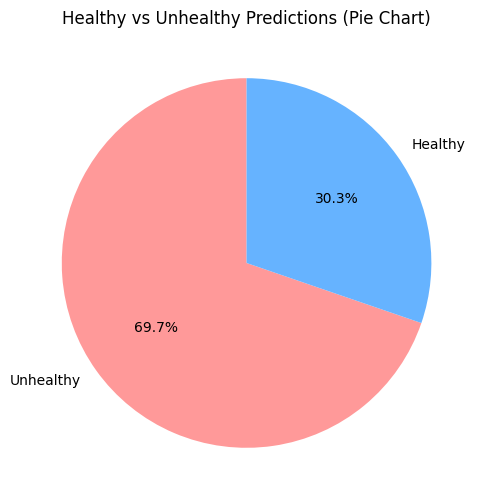

In [5]:
# Assuming you have predictions in y_pred_binary
labels = ['Unhealthy', 'Healthy']
sizes = [sum([1 for x in y_pred_binary if x == 0]), sum([1 for x in y_pred_binary if x == 1])]

# Plot Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title("Healthy vs Unhealthy Predictions (Pie Chart)")
plt.show()


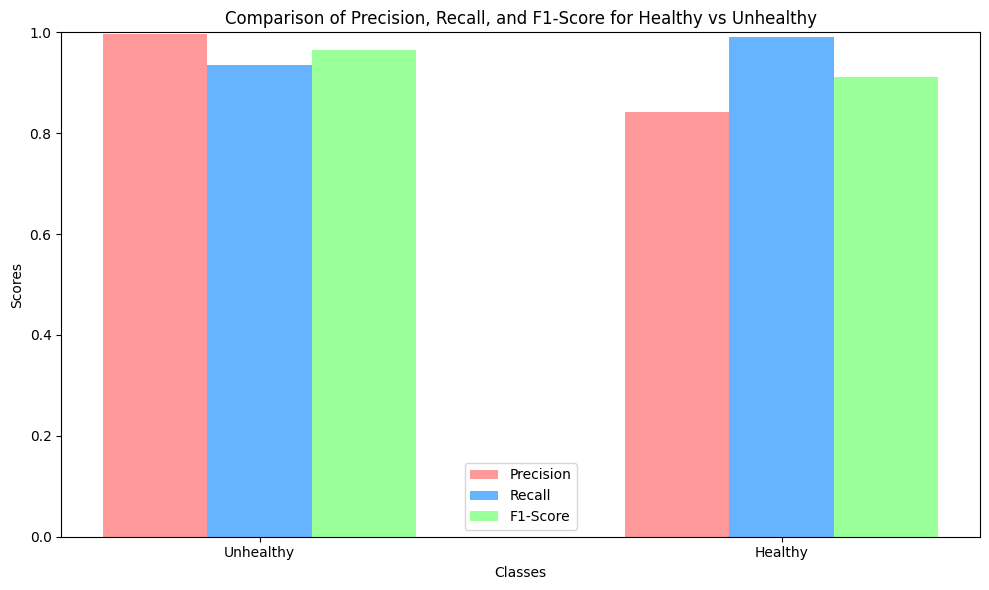

In [6]:
report = classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"], output_dict=True)
metrics = {
    'Precision': [report['Unhealthy']['precision'], report['Healthy']['precision']],
    'Recall': [report['Unhealthy']['recall'], report['Healthy']['recall']],
    'F1-Score': [report['Unhealthy']['f1-score'], report['Healthy']['f1-score']]
}



# Create an array for the x-axis positions of each group (Healthy, Unhealthy)
x = np.arange(2)  # Two classes: Unhealthy and Healthy
width = 0.2  # The width of the bars

# Create a single figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for each metric
ax.bar(x - width, metrics['Precision'], width, label='Precision', color='#ff9999')
ax.bar(x, metrics['Recall'], width, label='Recall', color='#66b3ff')
ax.bar(x + width, metrics['F1-Score'], width, label='F1-Score', color='#99ff99')

# Add labels and title
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Precision, Recall, and F1-Score for Healthy vs Unhealthy')
ax.set_xticks(x)
ax.set_xticklabels(['Unhealthy', 'Healthy'])
ax.set_ylim(0, 1)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [10]:
# Save the Model
mobilenet_model.save('mobilenet_plant_disease_model.keras')


In [11]:
mobilenet_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 4,282,545 (16.34 MB)

 Trainable params: 674,853 (2.57 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,349,708 (5.15 MB)